# 06 - Train/Test Split + PCA

**Objectif** : Séparer les données en train/test, puis appliquer la PCA pour réduire la dimension.

**Étapes** :
1. Chargement de X et y (sortie du notebook 05)
2. Train/Test Split (70/30, stratifié)
3. Vérification de la distribution des classes
4. PCA (95% de la variance, fit sur train uniquement)
5. Visualisations (variance expliquée cumulée)
6. Sauvegarde des données prêtes pour la modélisation

**Principe clé** : La PCA est fit uniquement sur X_train, puis appliquée sur X_test → pas de data leakage.

## 1. Chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Charger X et y sauvegardés par le notebook 05
X = np.load('../data/processed/X_features.npy')
y = np.load('../data/processed/y_target.npy')

# Charger les noms de features (utile pour l'analyse)
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()

print(f"X shape : {X.shape} ({X.shape[0]} films, {X.shape[1]} features)")
print(f"y shape : {y.shape}")
print(f"\nDistribution des classes :")
unique, counts = np.unique(y, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Classe {int(c)} : {n} films ({n/len(y)*100:.1f}%)")

X shape : (16312, 325) (16312 films, 325 features)
y shape : (16312,)

Distribution des classes :
  Classe 0 : 3258 films (20.0%)
  Classe 1 : 3524 films (21.6%)
  Classe 2 : 3103 films (19.0%)
  Classe 3 : 3165 films (19.4%)
  Classe 4 : 3262 films (20.0%)


## 2. Train/Test Split

- **80% train / 20% test** (proportions standard)
- **stratify=y** : garantit que chaque classe est représentée proportionnellement dans train et test
- **random_state=42** : reproductibilité

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (13049, 325)
X_test  : (3263, 325)
y_train : (13049,)
y_test  : (3263,)


In [3]:
import numpy as np

np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_test.npy", y_test)

print("✅ Données train/test sauvegardées")


✅ Données train/test sauvegardées


In [4]:
# --- Vérification : distribution des classes dans train et test ---
print("=== Distribution des classes ===")
print(f"{'Classe':<10} {'Train':<15} {'Test':<15}")
print("-" * 40)

for c in sorted(np.unique(y)):
    n_train = (y_train == c).sum()
    n_test = (y_test == c).sum()
    pct_train = n_train / len(y_train) * 100
    pct_test = n_test / len(y_test) * 100
    print(f"{int(c):<10} {n_train} ({pct_train:.1f}%)     {n_test} ({pct_test:.1f}%)")

print(f"\n✅ Les classes sont bien équilibrées dans train et test (grâce à stratify).")

=== Distribution des classes ===
Classe     Train           Test           
----------------------------------------
0          2606 (20.0%)     652 (20.0%)
1          2819 (21.6%)     705 (21.6%)
2          2482 (19.0%)     621 (19.0%)
3          2532 (19.4%)     633 (19.4%)
4          2610 (20.0%)     652 (20.0%)

✅ Les classes sont bien équilibrées dans train et test (grâce à stratify).


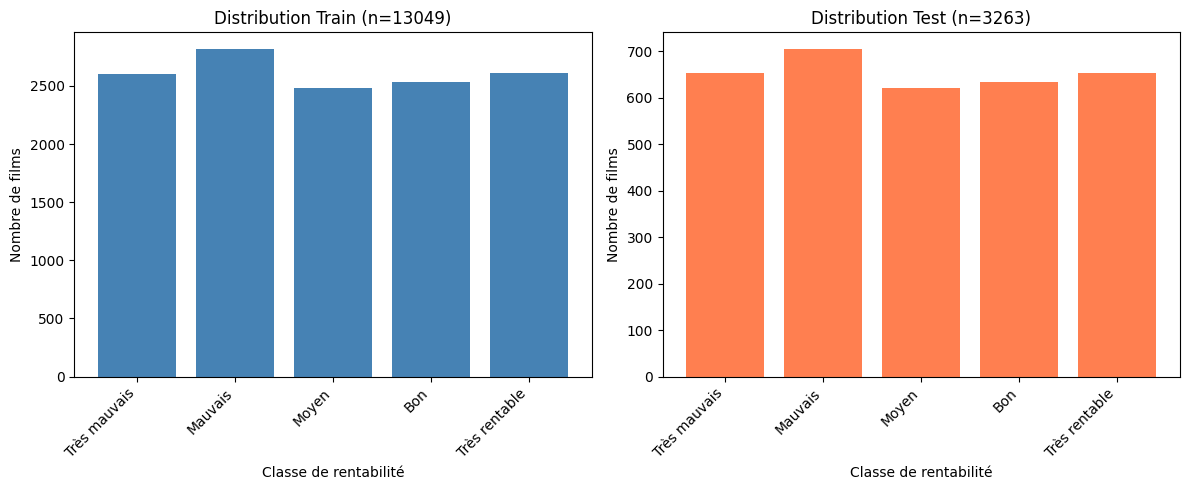

In [5]:
# --- Visualisation : distribution train vs test ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_classes = ['Très mauvais', 'Mauvais', 'Moyen', 'Bon', 'Très rentable']

# Train
unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(unique_train, counts_train, color='steelblue')
axes[0].set_title(f'Distribution Train (n={len(y_train)})')
axes[0].set_xlabel('Classe de rentabilité')
axes[0].set_ylabel('Nombre de films')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(labels_classes, rotation=45, ha='right')

# Test
unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(unique_test, counts_test, color='coral')
axes[1].set_title(f'Distribution Test (n={len(y_test)})')
axes[1].set_xlabel('Classe de rentabilité')
axes[1].set_ylabel('Nombre de films')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(labels_classes, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/figures/distribution_train_test.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Sauvegarde des données pour la modélisation

Ces fichiers seront utilisés par :
- **Hawa** → notebook 07 : Random Forest
- **Oumar** → notebook 08 : XGBoost

In [6]:
import joblib

# Sauvegarder les données SANS PCA
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy', y_test)


print("✅ Fichiers sauvegardés :")
print(f"  → X_train.npy  {X_train.shape}")
print(f"  → X_test.npy   {X_test.shape}")
print(f"  → y_train.npy  {y_train.shape}")
print(f"  → y_test.npy   {y_test.shape}")

✅ Fichiers sauvegardés :
  → X_train.npy  (13049, 325)
  → X_test.npy   (3263, 325)
  → y_train.npy  (13049,)
  → y_test.npy   (3263,)


In [7]:
print("=" * 60)
print("       RÉSUMÉ — DONNÉES PRÊTES POUR LA MODÉLISATION")
print("=" * 60)
print(f"")
print(f"  Films total       : {len(y)}")
print(f"  Train             : {len(y_train)} films (80%)")
print(f"  Test              : {len(y_test)} films (20%)")
print(f"")
print(f"  Features          : {X_train.shape[1]}")
print(f"")
print(f"  Classes (y)       : 5 (0=Très mauvais → 4=Très rentable)")
print(f"  Stratification    : ✅ Oui")
print(f"  Data leakage      : ✅ Aucun")
print(f"")
print(f"  → Prêt pour notebook 07 (Random Forest)")
print(f"  → Prêt pour notebook 08 (XGBoost)")
print("=" * 60)

       RÉSUMÉ — DONNÉES PRÊTES POUR LA MODÉLISATION

  Films total       : 16312
  Train             : 13049 films (80%)
  Test              : 3263 films (20%)

  Features          : 325

  Classes (y)       : 5 (0=Très mauvais → 4=Très rentable)
  Stratification    : ✅ Oui
  Data leakage      : ✅ Aucun

  → Prêt pour notebook 07 (Random Forest)
  → Prêt pour notebook 08 (XGBoost)
